In [1]:
#importing necessary libraries for data manupulation, analysis and visualization 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from nltk.sentiment import SentimentIntensityAnalyzer 
import re 
from collections import Counter
import nltk
nltk.download('vader_lexicon') #downloading VADER lexicon for sentiment analysis

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [2]:
print("="*60)
print("Step 1: DATA LOADING AND FILTERING")
print("="*60)

#loading app metadata dataset 
google_playstore_apps_df= pd.read_csv('googleplaystore.csv')
#loading user reviews dataset
google_playstore_reviews_df= pd.read_csv('googleplaystore_user_reviews.csv') 

#Filtering apps to Health & Fitness category and top 30 by number of reviews (converting 'Reviews' to numeric)
health_fitness_apps_df= google_playstore_apps_df [(
    google_playstore_apps_df['Category'].str.contains('HEALTH|FITNESS', case=False,na=False)) | 
    (google_playstore_apps_df['Category'] == 'HEALTH_AND_FITNESS')
].copy()
health_fitness_apps_df['Reviews_numeric']= pd.to_numeric(health_fitness_apps_df['Reviews'], errors='coerce')
top_health_apps_df= health_fitness_apps_df.nlargest(30, 'Reviews_numeric').copy()

#merging reviews with top health apps metadata on 'App' column
merged_reviews_df= pd.merge(google_playstore_reviews_df, top_health_apps_df[['App', 'Rating']], on='App', how='inner')
print(f"Shape after filtering:{merged_reviews_df.shape}") 

Step 1: DATA LOADING AND FILTERING
Shape after filtering:(1660, 6)


In [5]:
print("="*60)
print("Step 2: DATA CLEANING")
print("="*60)

#Removing rows with null, empty, or NaN TranslatedReviews
clean_reviews_df= merged_reviews_df[
    merged_reviews_df['Translated_Review'].notna() &
    (merged_reviews_df['Translated_Review'].str.len()>10) &
    (merged_reviews_df['Translated_Review'] != 'nan') &
    (merged_reviews_df['Translated_Review'].str.strip() != '') 
].copy()

#remoivng exact duplicates based on app and translated_review 
clean_reviews_df.drop_duplicates(subset=['App', 'Translated_Review'], inplace= True) 

#converting data types: Rating to float, SentimentPolarity/subjectivity to float, translated_review to string
numeric_cols= ['Rating', 'Sentiment_Polarity', 'Sentiment_Subjectivity']
clean_reviews_df[numeric_cols] = clean_reviews_df[numeric_cols].apply(pd.to_numeric, errors='coerce')
clean_reviews_df['Translated_Review'] = clean_reviews_df['Translated_Review'].astype(str)

print(f"Clean dataset shape: {clean_reviews_df.shape}")
print(clean_reviews_df.info()) #to verify dtypes and no nulls in key columns

clean_reviews_df.to_csv('clean_health_reviews.csv', index=False)
print("Saved clean_helath_reviews.csv")

Step 2: DATA CLEANING
Clean dataset shape: (168, 6)
<class 'pandas.core.frame.DataFrame'>
Index: 168 entries, 0 to 1658
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     168 non-null    object 
 1   Translated_Review       168 non-null    object 
 2   Sentiment               168 non-null    object 
 3   Sentiment_Polarity      168 non-null    float64
 4   Sentiment_Subjectivity  168 non-null    float64
 5   Rating                  168 non-null    float64
dtypes: float64(3), object(3)
memory usage: 9.2+ KB
None
Saved clean_helath_reviews.csv


In [4]:
print("="*60)
print("Step 3: DESCRIPTIVE ANALYSIS")
print("="*60)

#Rating distribution: counts and percentages 
rating_distribution = clean_reviews_df['Rating'].value_counts().sort_index()
rating_percentages = (rating_distribution / len(clean_reviews_df) * 100).round(2)

#review length analysis
clean_reviews_df ['ReviewLength'] = clean_reviews_df['Translated_Review'].str.len()
review_length_stats = clean_reviews_df.groupby('Rating') ['ReviewLength'].agg(['mean', 'median', 'min', 'max']).round(2) 

#Sentiment distribution (using pre-labeled if available)
sentiment_counts = clean_reviews_df['Sentiment'].value_counts() 
sentiment_percentages = (sentiment_counts / len(clean_reviews_df) * 100).round(2) 

#Top 5 apps by review count and thei avg rating/sentiment 
app_counts = clean_reviews_df['App'].value_counts().head(5).index
top_apps_stats = clean_reviews_df[clean_reviews_df['App'].isin(app_counts)].groupby('App').agg({'Rating':'mean', 'Sentiment': lambda x: (x=='Positive').mean() * 100}).round(2)
print("Rating Distribution:\n", pd.concat([rating_distribution, rating_percentages], axis=1))
print("Review Length by Rating:\n", review_length_stats)
print("Sentiment Distribution:\n", pd.concat([sentiment_counts, sentiment_percentages], axis=1))
print("\nTop Apps Stats:\n", top_apps_stats)

Step 3: DESCRIPTIVE ANALYSIS
Rating Distribution:
         count  count
Rating              
3.9         6   3.57
4.5        11   6.55
4.6        95  56.55
4.8        56  33.33
Review Length by Rating:
           mean  median  min  max
Rating                          
3.9     254.17   219.0  194  408
4.5      78.00    69.0   23  148
4.6     146.23   110.0   12  538
4.8     133.48   113.0   13  451
Sentiment Distribution:
            count  count
Sentiment              
Positive     128  76.19
Negative      21  12.50
Neutral       19  11.31

Top Apps Stats:
                                             Rating  Sentiment
App                                                          
30 Day Fitness Challenge - Workout at Home     4.8      86.67
7 Minute Workout                               4.5      90.91
Calorie Counter - MyFitnessPal                 4.6      66.32
Fitbit                                         3.9      83.33
Home Workout - No Equipment                    4.8      92.31


In [5]:
print("="*60)
print("Step 4: VADER SENTIMENT VALIDATION")
print("="*60)

#Initializing VADER sentiment analyzer 
vader_analyzer = SentimentIntensityAnalyzer()

#To get VADER compound score and classify
def get_vader_sentiment(review_text):
    scores = vader_analyzer.polarity_scores(review_text)
    compound = scores['compound']
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

#applying VADER to clean reviews
clean_reviews_df[['VaderSentiment', 'VaderCompound']] =clean_reviews_df['Translated_Review'].apply(
    lambda x: pd.Series([get_vader_sentiment(x), vader_analyzer.polarity_scores(x) ['compound']]))

#agreement accuracy with pre-labeled (where available)
accuracy = (clean_reviews_df['Sentiment'] == clean_reviews_df['VaderSentiment']).mean()
print(F"VADER Agreement Accuracy:{accuracy:.2%}")

Step 4: VADER SENTIMENT VALIDATION
VADER Agreement Accuracy:79.17%


Step 5 & 7: CORRELATION & VISUALS
SKIPPED STEP 6 BECAUSE NO REVIEW DATES AVAILABLE
Sentiment by Rating %:
 VaderSentiment   Negative    Neutral   Positive
Rating                                         
3.9             50.000000   0.000000  50.000000
4.5              9.090909   0.000000  90.909091
4.6             15.789474  18.947368  65.263158
4.8              5.357143   1.785714  92.857143

Avg Polarity by rating:
 Rating
3.9    0.072500
4.5    0.667927
4.6    0.398177
4.8    0.643673
Name: VaderCompound, dtype: float64


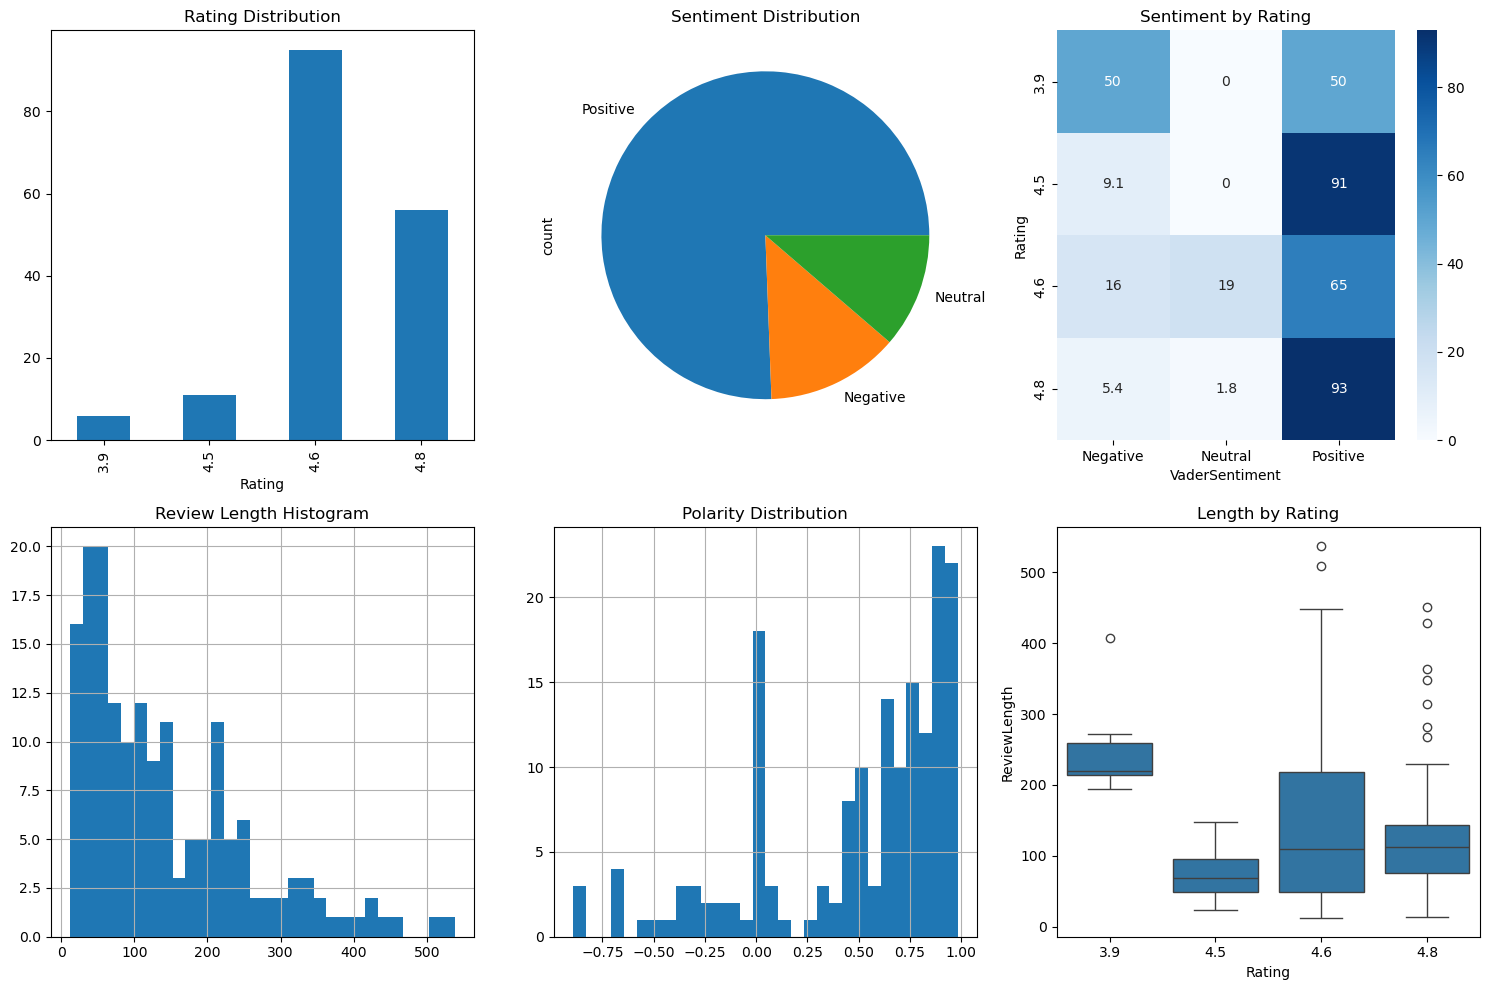

In [6]:
print("="*60)
print("Step 5 & 7: CORRELATION & VISUALS")
print("SKIPPED STEP 6 BECAUSE NO REVIEW DATES AVAILABLE")
print("="*60)

#Rating vs. Sentiment crosstab
crosstab = pd.crosstab(clean_reviews_df['Rating'],
                       clean_reviews_df['VaderSentiment'], normalize='index') * 100

#Polarity by rating
polarity_by_rating = clean_reviews_df.groupby('Rating')['VaderCompound'].mean()
print("Sentiment by Rating %:\n", crosstab)
print("\nAvg Polarity by rating:\n", polarity_by_rating)

#Visualization 
fig, axes = plt.subplots(2,3, figsize=(15,10))
rating_dist = clean_reviews_df['Rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0,0], title='Rating Distribution')
sentiment_pie = clean_reviews_df['VaderSentiment'].value_counts().plot(kind='pie', ax=axes[0,1], title='Sentiment Distribution')
sns.heatmap(crosstab, annot=True, ax=axes[0,2], cmap='Blues')
axes[0,2].set_title('Sentiment by Rating')
clean_reviews_df['ReviewLength'].hist(bins=30, ax=axes[1,0])
axes[1,0].set_title('Review Length Histogram')
clean_reviews_df['VaderCompound'].hist(bins=30, ax=axes[1,1])
axes[1,1].set_title('Polarity Distribution')
sns.boxplot(x='Rating', y='ReviewLength', data=clean_reviews_df, ax=axes[1,2])
axes[1,2].set_title('Length by Rating')
plt.tight_layout()
plt.savefig('milestone1.visuals.png')
plt.show()

In [7]:
print("="*60)
print("ADDITIONAL STEP: APP GROWTH ANALYSIS - DATE EXTRACTION (dd-mm-yyyy)")


# Reload full apps data
df_apps = pd.read_csv('googleplaystore.csv')

# Convert to datetime
df_apps['Date'] = pd.to_datetime(df_apps['Last Updated'], format='%B %d, %Y', errors='coerce')

# Dropping invalid dates
df_apps_valid = df_apps.dropna(subset=['Date']).copy()
print(f"Valid dates: {len(df_apps_valid)} / {len(df_apps)} rows ({len(df_apps_valid)/len(df_apps)*100:.1f}%)")

# Converting to dd-mm-yyyy format
df_apps_valid['Date_DMY'] = df_apps_valid['Date'].dt.strftime('%d-%m-%Y')

# Clean Installs
df_apps_valid['Installs_clean'] = df_apps_valid['Installs'].str.replace('+', '').str.replace(',', '').astype(float)

# YearMonth for grouping
df_apps_valid['YearMonth'] = df_apps_valid['Date'].dt.to_period('M')


print('-'*60)
print("HEALTH & FITNESS: COMPLETE DATE HIERARCHY (APP INSTALLS OVER TIME)")
print('='*60)

# Filtering ALL Health/Fitness apps
health_temporal = df_apps_valid[
    df_apps_valid['Category'].str.contains('HEALTH|FITNESS', case=False, na=False)
].copy()

# Parsing
health_temporal['Date'] = pd.to_datetime(health_temporal['Date'], errors='coerce')
health_temporal['Year'] = health_temporal['Date'].dt.year
health_temporal['Month'] = health_temporal['Date'].dt.month_name()
health_temporal['MonthNum'] = health_temporal['Date'].dt.month  #for sorting

print(f"{len(health_temporal)} records")

# Aggregating: Date | Year | Month | Installs
health_monthly = health_temporal.groupby(['Date', 'Year', 'Month', 'MonthNum'])['Installs_clean'].sum().reset_index()
health_monthly = health_monthly.sort_values(['Date', 'Year', 'MonthNum'])

print("Hierarchy Preview (Last 12):\n", health_monthly.tail(12)[['Date', 'Year', 'Month', 'Installs_clean']])

# Stats
total = health_monthly['Installs_clean'].sum()
print(f"Total Installs: {total:,.0f}")

#Exporting for storytelling
cols = ['Date', 'Year', 'Month', 'MonthNum', 'Installs_clean']
health_monthly[cols].to_csv('health_fitness_DMY.csv', index=False)
print("EXPORTED: health_fitness_DMY.csv")

ADDITIONAL STEP: APP GROWTH ANALYSIS - DATE EXTRACTION (dd-mm-yyyy)
Valid dates: 10840 / 10841 rows (100.0%)
------------------------------------------------------------
HEALTH & FITNESS: COMPLETE DATE HIERARCHY (APP INSTALLS OVER TIME)
341 records
Hierarchy Preview (Last 12):
           Date  Year   Month  Installs_clean
136 2018-07-28  2018    July      11010000.0
137 2018-07-29  2018    July        500000.0
138 2018-07-30  2018    July       5060000.0
139 2018-07-31  2018    July     797501000.0
140 2018-08-01  2018  August     118061000.0
141 2018-08-02  2018  August      35305200.0
142 2018-08-03  2018  August      58100000.0
143 2018-08-04  2018  August       4000000.0
144 2018-08-05  2018  August      10000000.0
145 2018-08-06  2018  August            10.0
146 2018-08-07  2018  August            10.0
147 2018-08-08  2018  August          1000.0
Total Installs: 1,583,072,512
EXPORTED: health_fitness_DMY.csv
